In [ ]:
import cuml.accel
cuml.accel.install()  # Must be called before other imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('data/delta_table_2020_3x3.csv')
df_2021 = pd.read_csv('data/delta_table_2021_3x3.csv')

df_2021 = df_2021[df_2021['delta_years'] != 5]

In [3]:
df_2020.shape, df_2021.shape

((2286815, 95), (2286815, 95))

In [4]:
df_2020.columns

Index(['delta_years', 'system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'bare_sparse_vegetation', 'built_up', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo', 'geometry', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B1

In [5]:
df_2020 = df_2020.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [6]:
df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland'
]


In [7]:
df_2020.columns

Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
       'B5_p0_p1', 'B6_p0_p1',

In [8]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [9]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_test = df_2021[target_labels]

In [10]:
X_train.columns, y_train.columns

(Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1',
        'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1',
        'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1',
        'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1',
        'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1',
        'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0',
        'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0',
        'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0',
        'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0',
        'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1',
        'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1',
        'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1',
        'B7_p0_p1', 'B8_p0_p1', 'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1',
        'B3_p1_p1', 'B4_p1_p1', 'B5

In [11]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [ ]:
models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=28, 
            weights='uniform', 
            metric='minkowski', 
            p=2, 
            leaf_size=24,
            n_jobs=-1
        ))
    ]),
    "Random Forest": RandomForestRegressor(
                                            n_estimators=390,
                                            random_state=42,
                                            max_depth=9,
                                            min_samples_split=14,
                                            min_samples_leaf=8,
                                            max_features=0.6061272316154472,
                                            n_jobs=-1
                                           ),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=600,
                                                 learning_rate=0.04475778468557638,
                                                 random_state=42,
                                                 max_depth=10,
                                                 gamma=1.0051560079684305,
                                                 min_child_weight=11,
                                                 reg_alpha=6.714222578424157,
                                                 reg_lambda=0.6964390261386526,
                                                 colsample_bytree=0.6983814307724542,
                                                 subsample=0.6876719545127158,
                                                 n_jobs=-1
                                                 ),
                                    n_jobs=-1
                                    ),
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.6599 | Test R2: 0.6566
Train RMSE: 0.1799 | Test RMSE: 0.1866

--- Ridge Regression ---
Train R2: 0.6586 | Test R2: 0.6557
Train RMSE: 0.1803 | Test RMSE: 0.1868

--- Lasso Regression ---
Train R2: 0.3754 | Test R2: 0.3640
Train RMSE: 0.2262 | Test RMSE: 0.2356



In [ ]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
5,XGBoost,0.110866,0.125411,0.897647,0.875238
3,KNN,0.120180,0.134037,0.884857,0.860306
4,Random Forest,0.133074,0.144753,0.855955,0.837465
0,Linear Regression,0.179904,0.189461,0.659918,0.647425
1,Ridge Regression,0.180338,0.189717,0.658634,0.646405
2,Lasso Regression,0.226217,0.237045,0.375352,0.359598


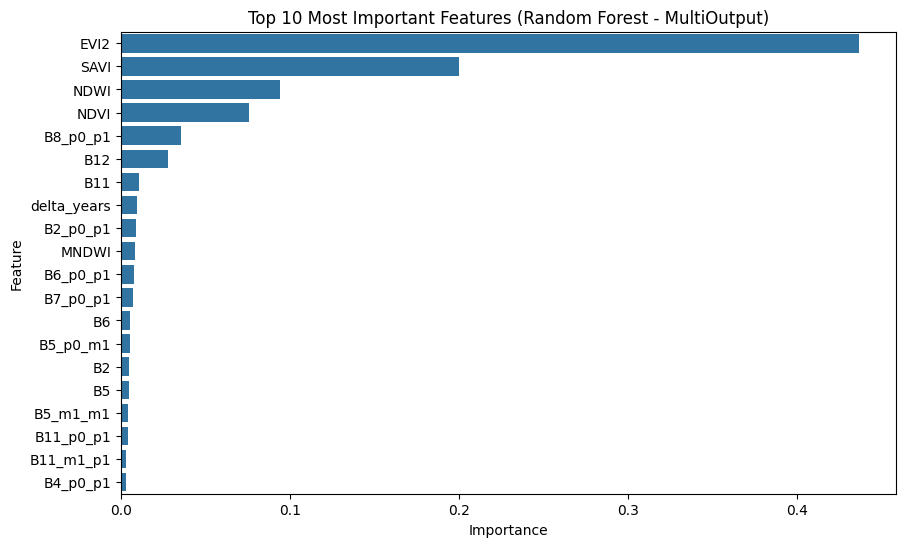

In [ ]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

current_labels = [
    'built_up',
    'vegetation',
    'water'
]

best_model_name = "XGBoost"
y_pred_array = models[best_model_name].predict(X_test)

y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

display(comparison_df.head(5))


,True_Dominant_Class,Pred_Dominant_Class,Match
0,built_up,built_up,True
1,built_up,built_up,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


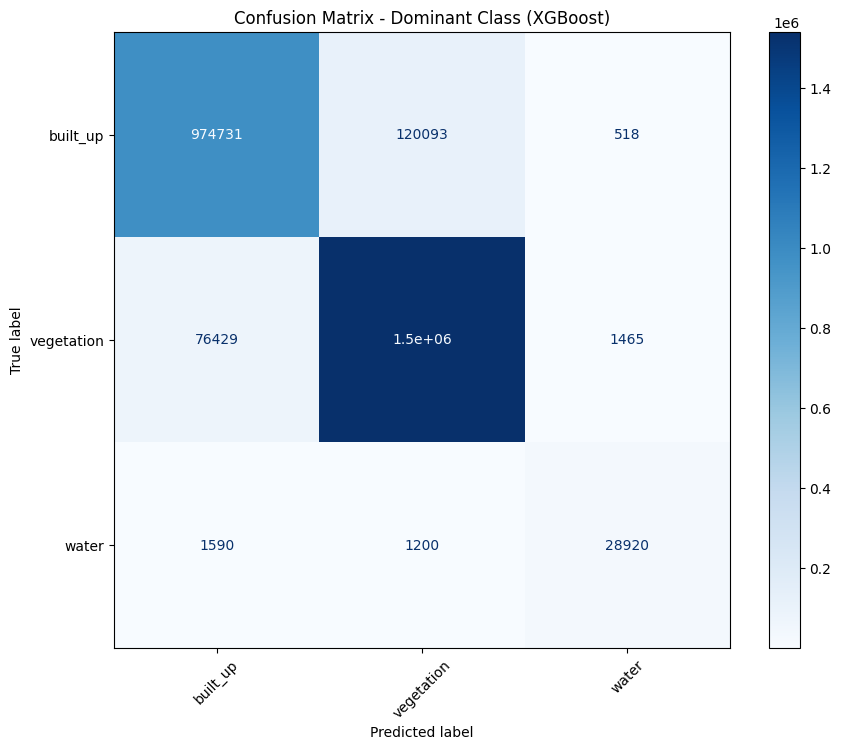

In [ ]:
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

In [ ]:
accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")

Overall Dominant Class Accuracy: 0.9266


In [ ]:
import joblib

# Define the filename
model_filename = 'models/all_benchmark_models_delta.joblib'

# Save the entire dictionary of models
joblib.dump(models, model_filename)

print(f"All models have been saved to {model_filename}")


""" 
# Load the dictionary back
loaded_models = joblib.load('all_benchmark_models.joblib')

# Access a specific model, for example, the XGBoost model
best_model = loaded_models['XGBoost']

# Make predictions (ensure X_test is in the same format)
# y_pred = best_model.predict(X_test)
"""